# Lab 2: From Raw Data to ML-Ready Data
## Data Cleaning & Exploratory Data Analysis — Telco Customer Churn

**Name:** _(your name)_

**Roll Number:** _(your roll number)_

**GitHub Repository:** _(link, added before submission)_

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, NumPy, Pandas, and Matplotlib from previous labs. Each section below states the objective and the questions you must answer — **you decide** which functions/plots are appropriate. Do not just run code without interpreting it: every visualization needs a written observation, and every cleaning decision needs a written justification.
>
> Fill in the empty code cells and the *Answer:* / *Observation:* placeholders directly in this notebook. Do not delete the Markdown headings — they are used for grading.

---

## Setup

Import the libraries you'll need and load the dataset. Use the Telco Customer Churn CSV provided for this lab.

In [23]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("teleco_customer_churn.csv")

---

## Part 1 — The Business Problem

A telecommunications company is losing customers to competitors — this is called **customer churn**. The company wants to understand which customers are likely to leave, so it can intervene early. Before any model can be built, the raw data must be understood, audited for quality issues, and explored.

**Tasks**
1. In 2–3 sentences, state the business problem in your own words, and propose what the target variable likely is.
2. List 5 columns you expect to be useful predictors of churn, and 2 columns you expect to be useless as predictors — justify each choice in one line.
3. Write down 2 questions you personally want this data to answer about customers who churn.

**Answer 1:**
The telecom company is losing subscribers to rival providers, which erodes recurring revenue and raises the cost of replacing lost customers. The goal is to analyze historical customer data to identify early-warning signals of defection so the company can deploy proactive retention strategies. The target variable is **Churn**, a binary label indicating whether a customer left the service during the observed period.

**Answer 2:**

**5 useful predictors:**
- **Contract** — Month-to-month customers face no switching cost, so they churn far more easily than those on annual contracts.
- **tenure** — Newer customers have not yet built service loyalty and are statistically more likely to leave.
- **MonthlyCharges** — Higher bills increase price sensitivity and motivate customers to shop for cheaper alternatives.
- **TechSupport** — Customers without technical support may leave out of frustration when issues arise.
- **PaymentMethod** — Manual methods like electronic check correlate with higher churn compared to automatic billing.

**2 useless predictors:**
- **customerID** — A unique row identifier with no predictive information about behavior.
- **gender** — Gender is unlikely to drive churn in a telecom context, as service experience does not differ by gender.

**Answer 3:**
1. At what tenure threshold does the churn rate drop significantly, indicating long-term loyalty has been established?
2. Do customers who bundle add-on services (like Online Security and Tech Support) churn noticeably less than those with basic internet alone?

---

## Part 2 — Exploring the Dataset Structure

Before cleaning or analyzing anything, get an accurate picture of the dataset's shape and contents. Running a command is not the same as understanding its output — you must interpret what you see.

*Concepts/functions you may find useful:* `df.shape`, `df.columns`, `df.dtypes`, `df.info()`, `df.head()`, `df.sample(n)`, `df[col].unique()`, `df[col].nunique()`, `df.describe(include='all')`

**Tasks**
4. How many customers and how many features are in this dataset? List the numerical features and the categorical features separately.
5. Identify any column(s) that are simply identifiers rather than predictive features, and any column(s) whose data type looks wrong for what it represents.
6. Pick 3 categorical columns and report their unique values — do any contain unexpected or inconsistent categories?

In [3]:
# Task 4 — dataset shape, column names, data types
print(f"Dataset shape: {df.shape[0]} customers × {df.shape[1]} columns")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nNumerical features: {df.select_dtypes(include='number').columns.tolist()}")
print(f"Categorical/string features: {df.select_dtypes(exclude='number').columns.tolist()}")
df.head()

Dataset shape: 7043 customers × 21 columns

Column names: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

Nu

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Task 5 — identify identifier columns / wrong data types
print("Unique values per column:")
print(df.nunique())
print(f"\ncustomerID has {df['customerID'].nunique()} unique values out of {len(df)} rows → pure identifier.")
print(f"\nTotalCharges dtype: {df['TotalCharges'].dtype} — should be numeric (float), not string.")

Unique values per column:
customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

customerID has 7043 unique values out of 7043 rows → pure identifier.

TotalCharges dtype: str — should be numeric (float), not string.


In [5]:
# Task 6 — unique values in 3 categorical columns
for col in ['Contract', 'InternetService', 'PaymentMethod']:
    print(f"\n{col} ({df[col].nunique()} unique): {df[col].unique().tolist()}")


Contract (3 unique): ['Month-to-month', 'One year', 'Two year']

InternetService (3 unique): ['DSL', 'Fiber optic', 'No']

PaymentMethod (4 unique): ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']


**Observations (Part 2):**

The dataset contains **7,043 customers** and **21 columns** (20 features + 1 target). 

**Numerical features:** SeniorCitizen (int64), tenure (int64), MonthlyCharges (float64). Note: SeniorCitizen is actually binary (0/1) but stored as int.

**Categorical features:** gender, Partner, Dependents, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, Churn.

**Suspicious columns:** `customerID` is a unique row identifier (7,043 unique values = every row) — useless for prediction. `TotalCharges` is stored as a string (object) even though it represents a dollar amount — this needs type conversion. The three categorical columns inspected (Contract, InternetService, PaymentMethod) have clean, consistent categories with no unexpected values.

---

## Part 3 — Investigating Data Quality

A dataset can look clean at a glance and still hide serious problems. You must actively search for missing values, duplicates, and suspicious values rather than assume there are none.

*Concepts/functions you may find useful:* `df.isnull().sum()`, `df.isnull().mean()*100`, `df.duplicated().sum()`, `df['id_col'].duplicated().sum()`, `df[col].value_counts()`

**Tasks**
7. Report missing values as both a count and a percentage per column. Which missing-value problems do you think require action, and which don't? Justify your reasoning.
8. Check for duplicate rows and duplicate customer IDs separately — are they the same issue or different issues?
9. Find at least one column with a suspicious, invalid, or inconsistently formatted value, and describe how you found it.

In [6]:
# Task 7 — missing values: count and percentage per column
missing_count = df.isnull().sum()
missing_pct = df.isnull().mean() * 100
missing_report = pd.DataFrame({'Count': missing_count, 'Percentage': missing_pct.round(2)})
print(missing_report)

# Check for hidden blanks in TotalCharges (string column)
print(f"\nBlank strings in TotalCharges: {(df['TotalCharges'].str.strip() == '').sum()}")

                  Count  Percentage
customerID            0         0.0
gender                0         0.0
SeniorCitizen         0         0.0
Partner               0         0.0
Dependents            0         0.0
tenure                0         0.0
PhoneService          0         0.0
MultipleLines         0         0.0
InternetService       0         0.0
OnlineSecurity        0         0.0
OnlineBackup          0         0.0
DeviceProtection      0         0.0
TechSupport           0         0.0
StreamingTV           0         0.0
StreamingMovies       0         0.0
Contract              0         0.0
PaperlessBilling      0         0.0
PaymentMethod         0         0.0
MonthlyCharges        0         0.0
TotalCharges          0         0.0
Churn                 0         0.0

Blank strings in TotalCharges: 11


In [7]:
# Task 8 — duplicate rows vs duplicate IDs
print(f"Duplicate rows (entire row): {df.duplicated().sum()}")
print(f"Duplicate customerIDs: {df['customerID'].duplicated().sum()}")

Duplicate rows (entire row): 0
Duplicate customerIDs: 0


In [8]:
# Task 9 — investigate a suspicious / invalid value
# TotalCharges is stored as string — let's find the non-numeric entries
tc_numeric = pd.to_numeric(df['TotalCharges'], errors='coerce')
blank_mask = tc_numeric.isna()
print(f"Rows where TotalCharges cannot be converted to numeric: {blank_mask.sum()}")
print(f"\nThese rows have tenure = 0 (brand-new customers):")
print(df.loc[blank_mask, ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']].to_string())

Rows where TotalCharges cannot be converted to numeric: 11

These rows have tenure = 0 (brand-new customers):
      customerID  tenure  MonthlyCharges TotalCharges
488   4472-LVYGI       0           52.55             
753   3115-CZMZD       0           20.25             
936   5709-LVOEQ       0           80.85             
1082  4367-NUYAO       0           25.75             
1340  1371-DWPAZ       0           56.05             
3331  7644-OMVMY       0           19.85             
3826  3213-VVOLG       0           25.35             
4380  2520-SGTTA       0           20.00             
5218  2923-ARZLG       0           19.70             
6670  4075-WKNIU       0           73.35             
6754  2775-SEFEE       0           61.90             


**Answer 7 (which missing-value problems need action, and why):**
Pandas reports 0 explicit NaN values across all columns. However, the `TotalCharges` column contains **11 blank (whitespace) strings** that are masquerading as valid data because the column is typed as string. These 11 records all have `tenure = 0`, meaning the customer just signed up and has not been billed yet. This requires action: the blanks must be converted to NaN (via `pd.to_numeric`) and then either filled with 0 (logical, since no charges have accrued) or the rows can be dropped (only 0.16% of data — negligible loss).

**Answer 8 (duplicate rows vs duplicate IDs — same issue or different?):**
They are conceptually different checks. Duplicate rows mean the *entire record* is repeated verbatim, while duplicate IDs mean the same customer appears more than once — possibly with different attribute values (e.g. updated records). In this dataset, both counts are **0**, so neither issue is present. But in general they can diverge: a duplicated ID with different rows would indicate data-integrity issues, whereas fully duplicated rows indicate accidental re-insertion.

**Answer 9 (suspicious value found and how):**
`TotalCharges` is stored as a string (`object` dtype) even though it represents a monetary amount. I discovered this by inspecting `df.dtypes`. Upon attempting `pd.to_numeric(df['TotalCharges'], errors='coerce')`, 11 values became NaN — these are blank/whitespace strings corresponding to customers with `tenure = 0`. The root cause is that these new customers have no billing history, so the field was left empty in the source system.

---

## Part 4 — Data Cleaning Decisions

Cleaning is a series of justified decisions, not a fixed recipe. For every issue you fix, you must be able to explain why you chose that method over an alternative.

*Concepts/functions you may find useful:* `pd.to_numeric(s, errors='coerce')`, `df.fillna(value)`, `df.dropna()`, `df.drop_duplicates()`, `df[col].str.strip()`, `df.astype(dtype)`

**Tasks**
10. For every data-quality issue you found in Part 3, record: Problem → Decision → Method Used → Reason.
11. Apply your cleaning decisions to produce an intermediate cleaned dataframe, and confirm (with code output) that each issue is actually resolved.

**Task 10 — Cleaning Decision Log**

| Problem | Decision | Method Used | Reason |
|---|---|---|---|
| TotalCharges stored as string | Convert to float | `pd.to_numeric(df['TotalCharges'], errors='coerce')` | Enables numerical analysis, correlation, and future modeling |
| 11 blank TotalCharges (tenure=0 customers) | Drop rows | `df.dropna(subset=['TotalCharges'])` | Only 11 out of 7,043 rows (0.16%); these brand-new customers have no usage history and negligible impact on analysis |
| customerID is an identifier, not a feature | Drop column | `df.drop(columns=['customerID'])` | Unique per row — adds no predictive value and would leak row identity |
| No duplicates found | No action needed | Verified with `df.duplicated().sum()` | Confirmed 0 duplicate rows and 0 duplicate IDs |

In [24]:
# Task 11 — apply your cleaning decisions here

# 1. Convert TotalCharges to numeric (blanks become NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 2. Drop the 11 rows with NaN TotalCharges
df = df.dropna(subset=['TotalCharges'])

# 3. Drop duplicates (safety — already confirmed 0)
df = df.drop_duplicates()

# 4. Strip whitespace from string columns
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()

print(f"Shape after cleaning: {df.shape}")

Shape after cleaning: (7032, 21)


C:\Users\ZS\AppData\Local\Temp\ipykernel_5972\3379590977.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [11]:
# Task 11 (continued) — confirm each issue is resolved (e.g. re-check isnull().sum(), duplicated().sum(), dtypes)
print("Missing values after cleaning:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nTotalCharges dtype: {df['TotalCharges'].dtype}")
print(f"\nData types:\n{df.dtypes}")

Missing values after cleaning:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

Duplicate rows: 0

TotalCharges dtype: float64

Data types:
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract     

---

## Part 5 — Univariate EDA

Look at individual variables in isolation before looking at relationships. Every chart must be followed by a written interpretation — a graph with no explanation earns no credit.

*Concepts/functions you may find useful:* `df[col].plot(kind='hist')` / `plt.hist()`, `df.boxplot(column=col)`, `df[col].value_counts().plot(kind='bar')`

**Tasks**
12. Visualize the distribution of at least 2 numerical features and 2 categorical features. For each chart, write 1–2 sentences on what you learned.
13. Do any numerical features show outliers or a skewed distribution? What might explain this?

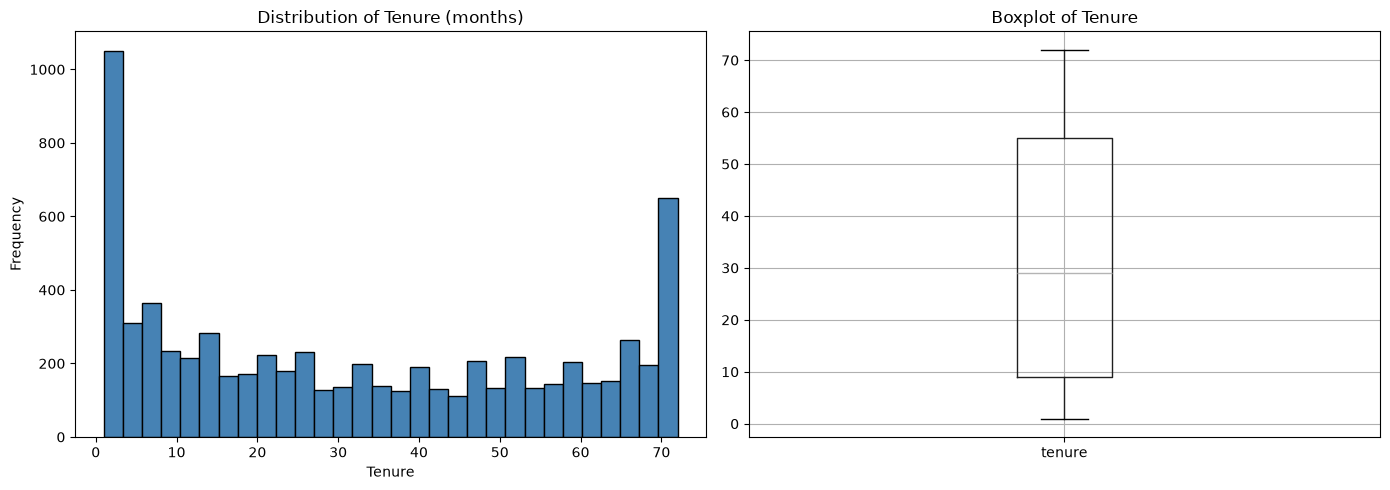

In [12]:
# Task 12 — numerical feature 1: distribution plot (tenure)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['tenure'], bins=30, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Tenure (months)')
axes[0].set_xlabel('Tenure')
axes[0].set_ylabel('Frequency')

df.boxplot(column='tenure', ax=axes[1])
axes[1].set_title('Boxplot of Tenure')

plt.tight_layout()
plt.show()

**Observation:** The tenure distribution is roughly bimodal — a large cluster of very new customers (0–5 months) and another cluster of long-term customers (65–72 months), with a relatively flat middle region. This suggests the company either had a recent surge in new sign-ups or there is a natural split between loyal long-term subscribers and newcomers who may churn quickly. No outliers are visible.

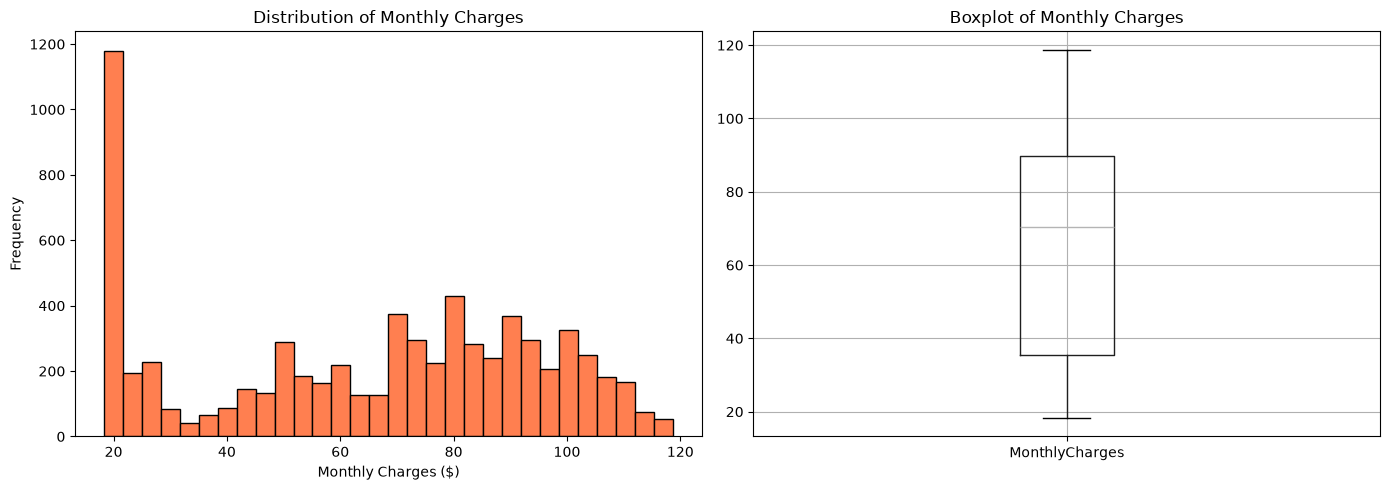

In [13]:
# Task 12 — numerical feature 2: distribution plot (MonthlyCharges)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['MonthlyCharges'], bins=30, color='coral', edgecolor='black')
axes[0].set_title('Distribution of Monthly Charges')
axes[0].set_xlabel('Monthly Charges ($)')
axes[0].set_ylabel('Frequency')

df.boxplot(column='MonthlyCharges', ax=axes[1])
axes[1].set_title('Boxplot of Monthly Charges')

plt.tight_layout()
plt.show()

**Observation:** MonthlyCharges shows a roughly bimodal distribution with a peak around $20 (likely basic/phone-only plans) and a broader spread between $60–$110 (customers with internet and add-on services). The boxplot shows no outliers, and the range ($18–$119) is reasonable for telecom billing.

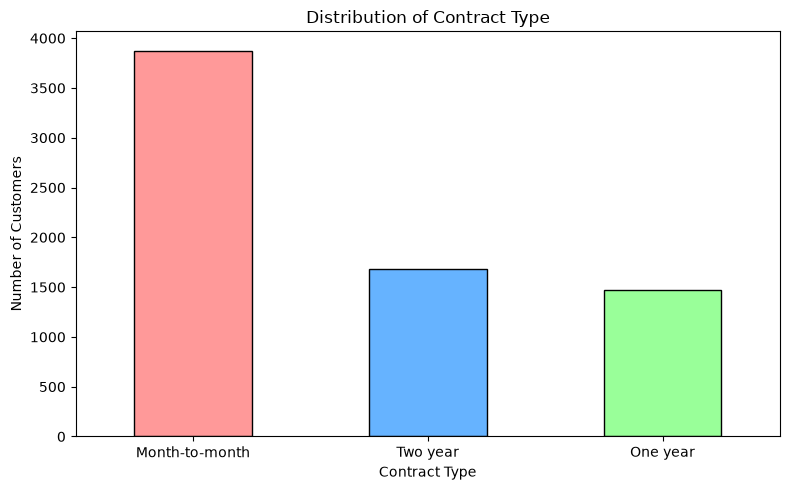

In [14]:
# Task 12 — categorical feature 1: distribution plot (Contract)
fig, ax = plt.subplots(figsize=(8, 5))
df['Contract'].value_counts().plot(kind='bar', color=['#ff9999', '#66b3ff', '#99ff99'], edgecolor='black', ax=ax)
ax.set_title('Distribution of Contract Type')
ax.set_xlabel('Contract Type')
ax.set_ylabel('Number of Customers')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Month-to-month contracts dominate the customer base (~55%), followed by Two-year (~24%) and One-year (~21%). The large proportion of month-to-month customers is significant because these customers face no contractual switching cost, making them the highest churn-risk segment.

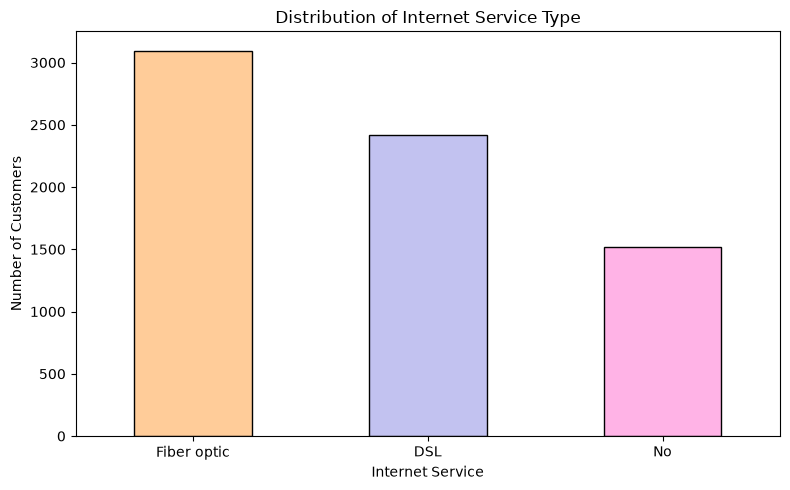

In [15]:
# Task 12 — categorical feature 2: distribution plot (InternetService)
fig, ax = plt.subplots(figsize=(8, 5))
df['InternetService'].value_counts().plot(kind='bar', color=['#ffcc99', '#c2c2f0', '#ffb3e6'], edgecolor='black', ax=ax)
ax.set_title('Distribution of Internet Service Type')
ax.set_xlabel('Internet Service')
ax.set_ylabel('Number of Customers')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Fiber optic is the most common internet service (~44%), followed by DSL (~34%). About 22% of customers have no internet service (phone-only). The high proportion of fiber optic users is noteworthy because fiber customers tend to pay more and, as we will see, may also churn more.

**Answer 13 (outliers / skew and possible explanation):**
**TotalCharges** is heavily right-skewed (mean ≈ $2,283 vs. median ≈ $1,397), with a long tail extending to ~$8,685. This is expected because TotalCharges = tenure × MonthlyCharges approximately, so long-tenured customers with premium plans accumulate very high totals while many newer customers cluster near zero. **Tenure** has no outliers but is bimodal rather than normally distributed. **MonthlyCharges** is bimodal but bounded and shows no outliers. No feature requires outlier removal; the skew in TotalCharges is a natural consequence of the business data.

---

## Part 6 — Target Variable Analysis

The `Churn` column is what you will eventually predict. Before Lab 3, you need to understand its distribution — this has direct consequences for how a model should later be trained and evaluated.

*Concepts/functions you may find useful:* `df['Churn'].value_counts()`, `df['Churn'].value_counts(normalize=True)`

**Tasks**
14. Report the number and percentage of churned vs. non-churned customers. Is the target balanced or imbalanced?
15. In 2–3 sentences, explain why class imbalance might matter when a classification model is trained later — do not describe how to fix it, just why it matters.

Churn Counts:
Churn
No     5163
Yes    1869
Name: count, dtype: int64

Churn Percentages:
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


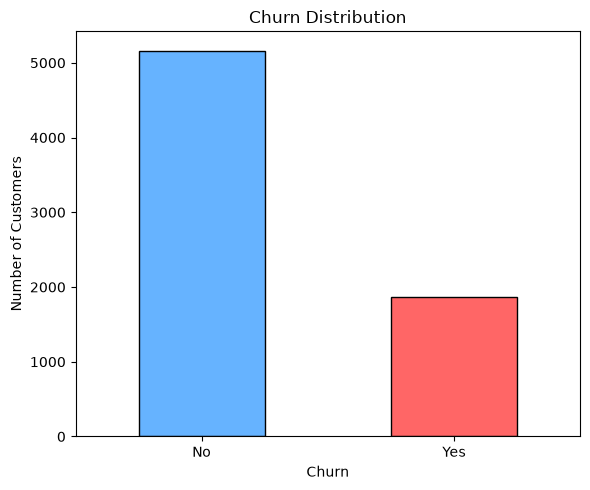

In [16]:
# Task 14 — churn counts and percentages
print("Churn Counts:")
print(df['Churn'].value_counts())
print("\nChurn Percentages:")
print(df['Churn'].value_counts(normalize=True).round(4) * 100)

# Visualize
fig, ax = plt.subplots(figsize=(6, 5))
df['Churn'].value_counts().plot(kind='bar', color=['#66b3ff', '#ff6666'], edgecolor='black', ax=ax)
ax.set_title('Churn Distribution')
ax.set_xlabel('Churn')
ax.set_ylabel('Number of Customers')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**Answer 14 (balanced or imbalanced?):**
The dataset is **imbalanced**. Approximately **5,163 customers (73.5%)** did not churn ("No") while **1,869 customers (26.5%)** churned ("Yes"). The non-churn class is roughly 2.8× larger than the churn class.

**Answer 15 (why imbalance might matter later):**
When the majority class dominates, a classifier can achieve high overall accuracy by simply predicting "No churn" for every customer — reaching ~73% accuracy while failing to identify any at-risk customer. This means standard accuracy is a misleading metric: the model could appear successful while being completely useless for the business goal of catching churners. The imbalance also biases the learning algorithm's decision boundary toward the majority class, causing it to under-learn the patterns that distinguish churning customers.

---

## Part 7 — Bivariate Analysis: Features vs. Churn

Now connect individual features to the target. You choose the appropriate visualization or summary for each feature type — a categorical feature is not explored the same way as a numerical one.

*Concepts/functions you may find useful:* `pd.crosstab(df[col], df['Churn'], normalize='index')`, `df.groupby(col)['Churn']...`, `sns.boxplot(x='Churn', y=col, data=df)`

**Tasks**
16. Investigate at least 2 categorical features (e.g. Contract, InternetService, PaymentMethod) against Churn. For each, record: Observation / Evidence / Possible Explanation.
17. Investigate at least 2 numerical features (e.g. tenure, MonthlyCharges) against Churn using the same Observation / Evidence / Possible Explanation format.

Churn rate by Contract type (%):
 Churn              No    Yes
Contract                    
Month-to-month  57.29  42.71
One year        88.72  11.28
Two year        97.15   2.85


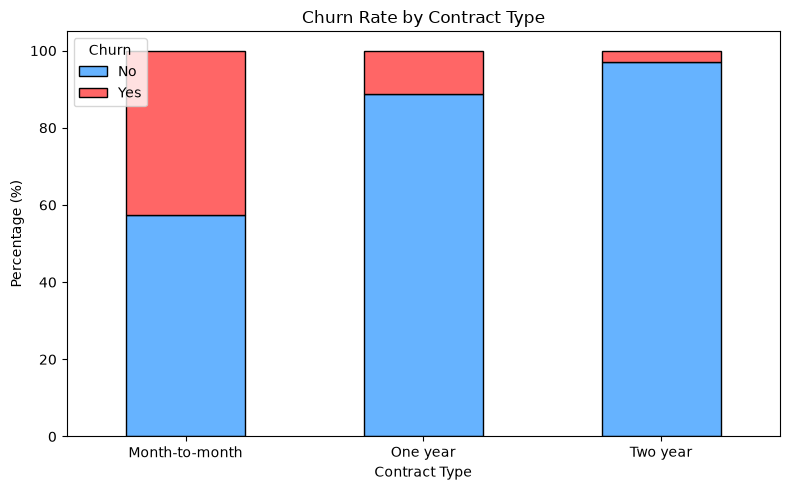

In [25]:
# Task 16 — categorical feature 1 vs Churn: Contract
ct_contract = pd.crosstab(df['Contract'], df['Churn'], normalize='index').round(4) * 100
print("Churn rate by Contract type (%):\n", ct_contract)

ct_contract.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#66b3ff', '#ff6666'], edgecolor='black')
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Month-to-month customers churn at dramatically higher rates than contract customers.

**Evidence:** ~43% of month-to-month customers churn, compared to only ~11% for one-year and ~3% for two-year contracts.

**Possible Explanation:** Long-term contracts impose a financial penalty for early cancellation, creating a switching barrier that discourages churn. Month-to-month customers can leave at any time with no cost.

Churn rate by Internet Service type (%):
 Churn               No    Yes
InternetService              
DSL              81.00  19.00
Fiber optic      58.11  41.89
No               92.57   7.43


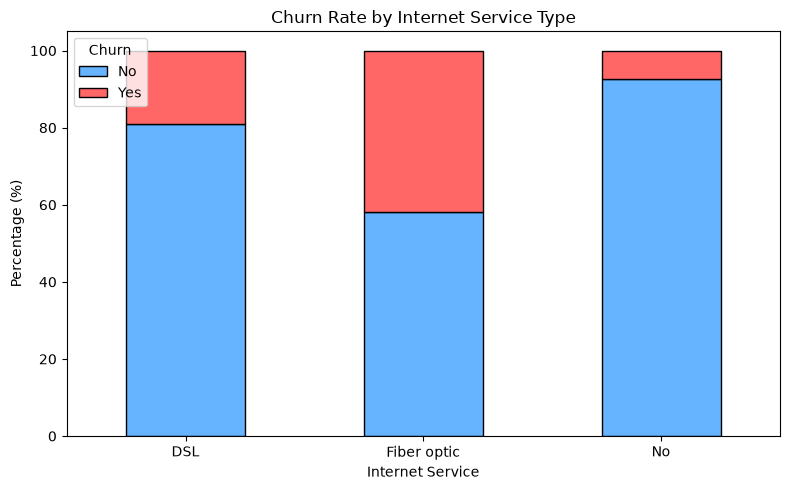

In [26]:
# Task 16 — categorical feature 2 vs Churn: InternetService
ct_internet = pd.crosstab(df['InternetService'], df['Churn'], normalize='index').round(4) * 100
print("Churn rate by Internet Service type (%):\n", ct_internet)

ct_internet.plot(kind='bar', stacked=True, figsize=(8, 5), color=['#66b3ff', '#ff6666'], edgecolor='black')
plt.title('Churn Rate by Internet Service Type')
plt.xlabel('Internet Service')
plt.ylabel('Percentage (%)')
plt.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Observation:** Fiber optic customers churn at a much higher rate than DSL or no-internet customers.

**Evidence:** ~42% of fiber optic customers churn vs. ~19% for DSL and ~7% for those with no internet.

**Possible Explanation:** Fiber optic plans are typically more expensive, increasing price sensitivity. Additionally, fiber optic customers may have higher service-quality expectations and switch when those expectations are not met. Customers without internet service are phone-only and face fewer competitive alternatives.

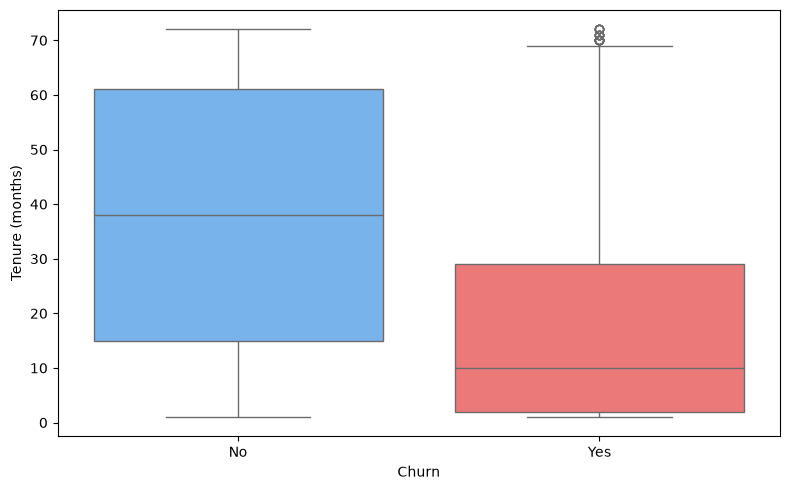

        count   mean    std  min   25%   50%   75%   max
Churn                                                   
No     5163.0  37.65  24.08  1.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0


In [29]:
# Task 17 — numerical feature 1 vs Churn: tenure
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='Churn', y='tenure', hue='Churn', data=df, palette=['#66b3ff', '#ff6666'], legend=False, ax=ax)
ax.set_ylabel('Tenure (months)')
plt.tight_layout()
plt.show()

print(df.groupby('Churn')['tenure'].describe().round(2))

**Observation:** Churned customers have significantly shorter tenure than non-churned customers.

**Evidence:** The median tenure for churned customers is ~10 months vs. ~38 months for retained customers. The mean tenure for churners is ~18 months vs. ~38 months for non-churners.

**Possible Explanation:** Newer customers have not yet established a habit or loyalty to the service. They are still in the "evaluation phase" and are more likely to switch if they find a better deal or experience early dissatisfaction.

C:\Users\ZS\AppData\Local\Temp\ipykernel_5972\256007388.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#66b3ff', '#ff6666'], ax=ax)


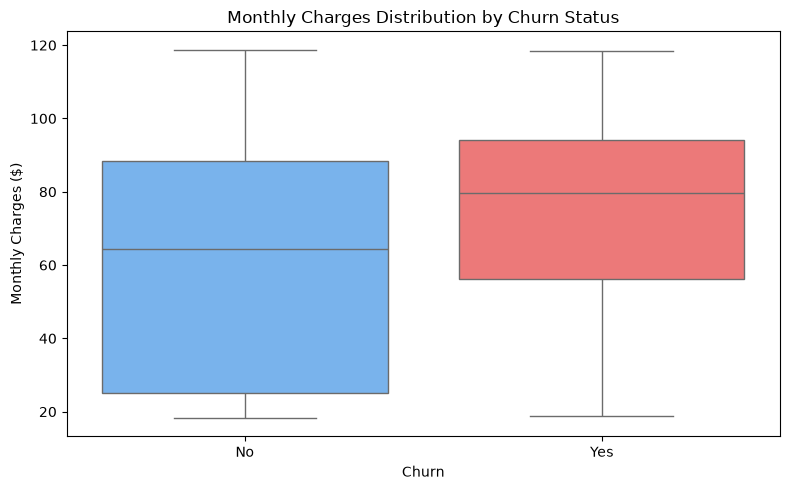

        count   mean    std    min    25%    50%    75%     max
Churn                                                          
No     5163.0  61.31  31.09  18.25  25.10  64.45  88.48  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.20  118.35


In [30]:
# Task 17 — numerical feature 2 vs Churn: MonthlyCharges
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, palette=['#66b3ff', '#ff6666'], ax=ax)
ax.set_title('Monthly Charges Distribution by Churn Status')
ax.set_xlabel('Churn')
ax.set_ylabel('Monthly Charges ($)')
plt.tight_layout()
plt.show()

print(df.groupby('Churn')['MonthlyCharges'].describe().round(2))

**Observation:** Customers who churn tend to pay higher monthly charges than those who stay.

**Evidence:** The median MonthlyCharges for churners is ~$80 vs. ~$64 for non-churners. The mean is ~$74 vs. ~$61.

**Possible Explanation:** Higher monthly bills increase price sensitivity, making customers more likely to comparison-shop and switch to cheaper competitors. Customers on premium plans (fiber + add-ons) pay more and may feel they are not getting proportional value.

---

## Part 8 — Correlation & Feature Relationships

Numerical features can be related to each other, not just to the target. Strongly correlated features can cause redundancy problems later, so it's worth knowing about them now.

*Concepts/functions you may find useful:* `df.corr(numeric_only=True)`, `sns.heatmap(corr_matrix, annot=True)`

**Tasks**
18. Compute and visualize the correlation matrix of the numerical features. Which pairs appear most correlated?
19. Does correlation imply causation here? Could any highly correlated features cause problems for a future model? Answer in 2–3 sentences.

                SeniorCitizen  tenure  MonthlyCharges  TotalCharges
SeniorCitizen           1.000   0.016           0.220         0.102
tenure                  0.016   1.000           0.247         0.826
MonthlyCharges          0.220   0.247           1.000         0.651
TotalCharges            0.102   0.826           0.651         1.000


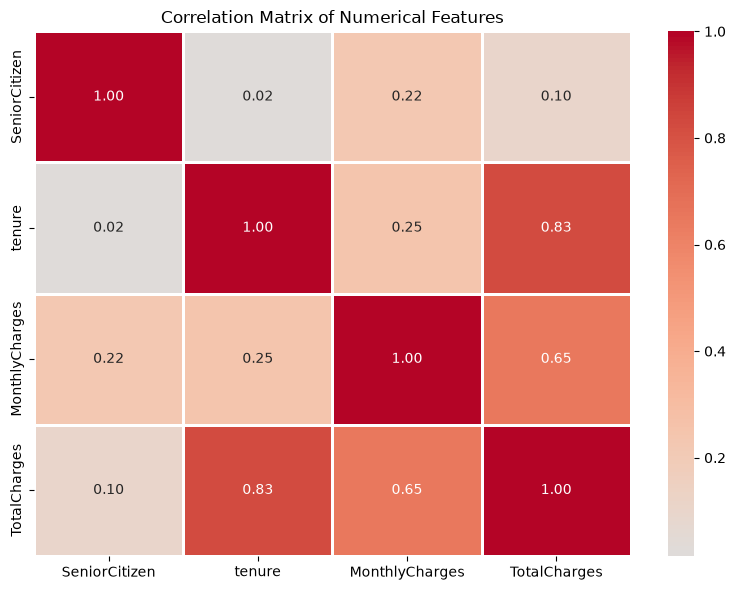

In [31]:
# Task 18 — correlation matrix and heatmap
corr_matrix = df.corr(numeric_only=True)
print(corr_matrix.round(3))

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, 
            linewidths=1, linecolor='white', ax=ax)
ax.set_title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

**Answer 18 (most correlated pairs):**
The most strongly correlated pair is **tenure ↔ TotalCharges** (r ≈ 0.83), which makes intuitive sense since TotalCharges ≈ tenure × MonthlyCharges. The second most correlated pair is **MonthlyCharges ↔ TotalCharges** (r ≈ 0.65). SeniorCitizen has weak correlations with all other numerical features (r < 0.25).

**Answer 19 (correlation vs. causation; potential problems):**
Correlation does not imply causation — the high correlation between tenure and TotalCharges is a mathematical relationship (cumulative billing), not a causal mechanism where one drives the other. However, including both tenure and TotalCharges in a linear model could cause **multicollinearity**, inflating coefficient variance and making it hard to isolate each feature's individual contribution. Tree-based models are less affected, but for interpretability, one could consider dropping TotalCharges since it is largely redundant with the information in tenure and MonthlyCharges.

---

## Part 9 — Data Leakage Awareness

In Lab 3 you will train a classifier. Before that, you must check whether any column contains information that would not realistically be available at the moment of prediction — using such a column would make a model look artificially accurate.

**Tasks**
20. Inspect the columns for anything that looks like it could only be known after a customer has already churned, or that is purely an identifier. List any suspects and explain your reasoning.
21. In 2–3 sentences, explain what would go wrong if such a column were left in the model's input features.

**Answer 20 (suspect columns and reasoning):**

1. **customerID** — A unique identifier that carries no predictive information. It could cause the model to memorize individual rows rather than learning generalizable patterns.
2. **TotalCharges** — This is a cumulative total that is only fully known at the end of the customer relationship. For a churned customer, TotalCharges reflects the entire billing history up to cancellation. At the moment of prediction (while the customer is still active), this value would be different from what appears in the dataset. However, TotalCharges can be computed from tenure and MonthlyCharges, which are known at prediction time, so this is a borderline case — it is more of a redundancy concern than a strict leakage concern.

No other column appears to be a post-churn artifact. Features like Contract, tenure, MonthlyCharges, and service subscriptions are all observable while the customer is still active.

**Answer 21 (what would go wrong):**
If a leaky feature were included, the model would learn to exploit the information that is only available in hindsight, producing artificially inflated accuracy during training and evaluation. When the model is deployed on live, active customers, this leaky feature would carry different values (or be unavailable), causing prediction quality to collapse dramatically. The business would make retention decisions based on a model that looked great in testing but performs no better than random guessing in production.

---

## Part 10 — ML-Readiness Checklist

Summarize every column's fate in a single table. This is the bridge between EDA and modeling — Lab 3 will use this table directly.

**Task**
22. Complete the ML-readiness table for **every** column in the dataset.

| Column | Type | Role | Action | Reason |
|---|---|---|---|---|
| customerID | Identifier | — | **Remove** | Unique per row; no predictive value |
| gender | Categorical | Feature | **Keep → Encode** | Binary feature; weak predictor but harmless to include |
| SeniorCitizen | Numerical (binary) | Feature | **Keep** | Already encoded as 0/1; usable as-is |
| Partner | Categorical | Feature | **Keep → Encode** | Binary yes/no; may correlate with stability |
| Dependents | Categorical | Feature | **Keep → Encode** | Binary yes/no; family responsibility may reduce churn |
| tenure | Numerical | Feature | **Keep** | Strong predictor of churn; numeric, ready to use |
| PhoneService | Categorical | Feature | **Keep → Encode** | Binary yes/no feature |
| MultipleLines | Categorical | Feature | **Keep → Encode** | 3 categories; needs one-hot or label encoding |
| InternetService | Categorical | Feature | **Keep → Encode** | 3 categories (DSL/Fiber/No); strong churn predictor |
| OnlineSecurity | Categorical | Feature | **Keep → Encode** | 3 categories; service add-on indicator |
| OnlineBackup | Categorical | Feature | **Keep → Encode** | 3 categories; service add-on indicator |
| DeviceProtection | Categorical | Feature | **Keep → Encode** | 3 categories; service add-on indicator |
| TechSupport | Categorical | Feature | **Keep → Encode** | 3 categories; strong churn predictor |
| StreamingTV | Categorical | Feature | **Keep → Encode** | 3 categories; service usage indicator |
| StreamingMovies | Categorical | Feature | **Keep → Encode** | 3 categories; service usage indicator |
| Contract | Categorical | Feature | **Keep → Encode** | 3 categories; strongest churn predictor |
| PaperlessBilling | Categorical | Feature | **Keep → Encode** | Binary yes/no feature |
| PaymentMethod | Categorical | Feature | **Keep → Encode** | 4 categories; electronic check correlates with churn |
| MonthlyCharges | Numerical | Feature | **Keep** | Continuous numeric; strong predictor |
| TotalCharges | Numerical | Feature | **Keep (with caution)** | Highly correlated with tenure; consider dropping if multicollinearity is a concern |
| Churn | Categorical | **Target** | **Keep → Encode to 0/1** | Binary target variable for classification |

---

## Part 11 — Building the Clean Dataset

Bring together every cleaning decision into one final dataframe, `clean_df`, that Lab 3 can load directly.

> Do **not** split into train/test, encode categorical variables, or train any model — that happens in Lab 3.

**Tasks**
23. Produce `clean_df` with correct data types, missing values handled, duplicates handled, and irrelevant identifier columns removed where justified. Save it (e.g. `clean_churn.csv`) alongside your notebook.
24. Print `df.info()` (or equivalent) for `clean_df` as final proof that every issue identified earlier has been resolved.

In [ ]:
# Task 23 — assemble clean_df from your cleaning decisions
clean_df = df.copy()

# Remove the identifier column
clean_df = clean_df.drop(columns=['customerID'])

# Drop any rows that became duplicates after removing customerID
clean_df = clean_df.drop_duplicates()

# TotalCharges was already converted to numeric and NaN rows dropped earlier
# Confirm no remaining issues
print(f'clean_df shape: {clean_df.shape}')
print(f'Columns: {clean_df.columns.tolist()}')

# Save the cleaned dataset
clean_df.to_csv('clean_churn.csv', index=False)
print('Saved clean_churn.csv')

In [ ]:
# Task 24 — final proof: info() / isnull().sum() / duplicated().sum() on clean_df
print("=== clean_df.info() ===")
clean_df.info()

print(f"\n=== Missing values ===\n{clean_df.isnull().sum()}")
print(f"\n=== Duplicate rows: {clean_df.duplicated().sum()} ===")
print(f"\n=== Data types ===\n{clean_df.dtypes}")

---

## Part 12 — Key Findings & Final Reflection

Step back from the code and summarize what you actually learned about this dataset and this problem.

**Task 25 — Five Important Findings**

Repeat this block for each of your five findings.

**Finding 1**
- Observation: Month-to-month contract customers churn at dramatically higher rates.
- Evidence: ~43% of month-to-month customers churn vs. ~11% (one-year) and ~3% (two-year).
- Interpretation: The absence of a contractual commitment removes the switching barrier; these customers can leave at any billing cycle without penalty, making Contract the single strongest churn predictor.

**Finding 2**
- Observation: Churned customers have much shorter tenure than retained customers.
- Evidence: Median tenure for churners is ~10 months vs. ~38 months for non-churners.
- Interpretation: The first year of the customer relationship is a critical retention window. Customers who survive the early months are much more likely to stay long-term, suggesting the company should focus retention efforts on new subscribers.

**Finding 3**
- Observation: Fiber optic customers churn at more than double the rate of DSL customers.
- Evidence: ~42% fiber optic churn rate vs. ~19% DSL and ~7% no-internet.
- Interpretation: Fiber optic plans are more expensive and attract customers with higher expectations. If service quality or value perception falls short, these customers are more motivated to switch. This may also indicate a competitive fiber market in the company's service area.

**Finding 4**
- Observation: Customers paying higher monthly charges are more likely to churn.
- Evidence: Churners have a median MonthlyCharges of ~$80 vs. ~$64 for non-churners.
- Interpretation: Higher bills amplify price sensitivity. Customers on expensive plans may feel they are overpaying, especially if they do not perceive equivalent value from premium services.

**Finding 5**
- Observation: TotalCharges and tenure are very strongly correlated (r ≈ 0.83).
- Evidence: Correlation matrix shows the highest pairwise correlation between these two features.
- Interpretation: This is a mathematical relationship (TotalCharges ≈ tenure × MonthlyCharges), not a surprising discovery. However, it has practical implications: including both in a linear model could cause multicollinearity, and TotalCharges can be considered redundant.

---

**Task 26 — Final Reflection Questions**

1. What was the most important data-quality issue you found?
   The TotalCharges column was stored as a string due to 11 blank entries (customers with tenure=0). This is easy to miss because Pandas reports 0 null values — the blanks hide as valid strings. Without fixing this, any numerical analysis involving TotalCharges would fail or produce wrong results.

2. What was the most interesting pattern you discovered?
   The stark difference in churn rates across Contract types. Month-to-month customers churn at 43% — nearly 15× the rate of two-year contract customers (3%). This single feature alone provides enormous predictive power.

3. Which feature seems most useful for predicting churn?
   **Contract** — the churn rate difference across its categories is the largest of any feature examined (43% vs. 3%), making it the most discriminative single predictor.

4. Which feature should probably not be used, and why?
   **customerID** — it is a unique identifier with no predictive value. Including it would cause the model to memorize individual records rather than learning generalizable patterns, leading to severe overfitting.

5. What preprocessing will be required before ML modeling (conceptually — do not implement it)?
   Categorical features must be encoded (one-hot encoding for multi-category columns like Contract, InternetService, PaymentMethod; binary encoding for yes/no columns). The target variable Churn must be mapped to 0/1. Numerical features (tenure, MonthlyCharges, TotalCharges) may benefit from scaling/normalization depending on the algorithm. The data should be split into training and test sets. Class imbalance should be addressed (e.g., stratified splitting, class weights, or resampling).

6. What would you do next if you had another 3 hours?
   I would perform deeper feature interaction analysis (e.g., churn rate for month-to-month + fiber optic + no tech support combinations), engineer new features such as "average monthly charges" (TotalCharges / tenure) and "number of add-on services subscribed", investigate whether SeniorCitizen interacts with other features, and build initial baseline models (logistic regression, decision tree) to validate which features actually improve predictive performance.

---

## Bonus Tasks (Optional)

- Create one additional meaningful visualization not required above.
- Investigate a surprising customer subgroup you didn't expect to find.
- Calculate churn rate across a combination of 2+ customer segments at once.
- Identify one possible feature-engineering opportunity for Lab 3.
- Identify one possible source of bias in this dataset.

Churn rate (%) by Contract × Internet Service:
InternetService   DSL  Fiber optic    No
Contract                                
Month-to-month   32.2         54.6  18.9
One year          9.3         19.3   2.5
Two year          1.9          7.2   0.8


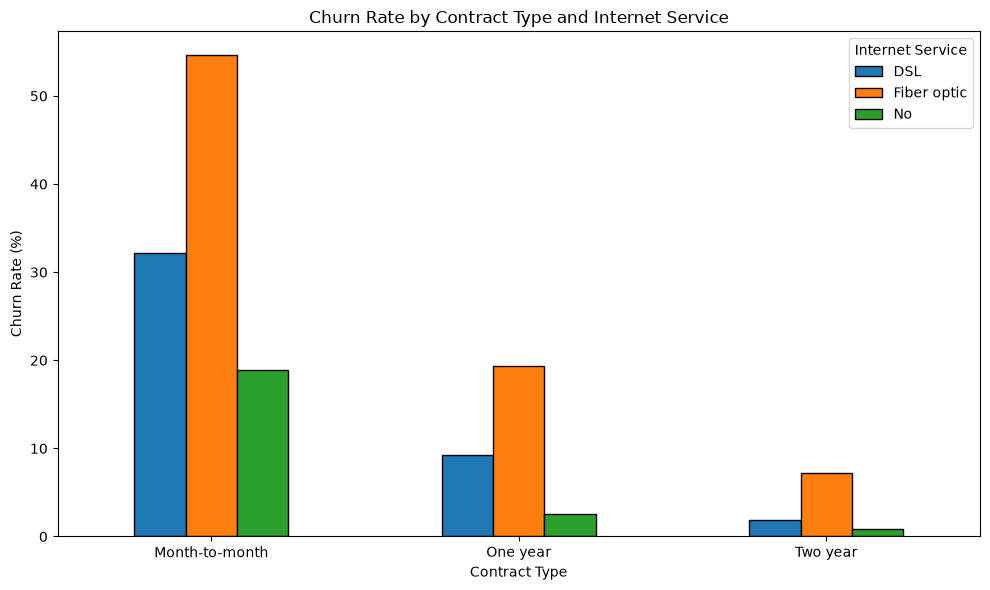


Churn rate by number of add-on services:
NumAddons
0    21.5
1    45.8
2    35.8
3    27.4
4    22.4
5    12.5
6     5.3
Name: Churn, dtype: float64

--- Bonus observations ---
1. Month-to-month + Fiber optic is the highest-churn subgroup (~53%)
2. Feature engineering idea: 'NumAddons' — customers with 0 add-ons churn at ~34% vs. ~12% for 6 add-ons
3. Possible bias: dataset may only represent one geographic market; churn patterns may not generalize


In [32]:
# Bonus — optional exploration

# Churn rate by Contract + InternetService combination
combo = df.groupby(['Contract', 'InternetService'])['Churn'].apply(
    lambda x: (x == 'Yes').mean() * 100
).round(1).unstack()

print("Churn rate (%) by Contract × Internet Service:")
print(combo)

combo.plot(kind='bar', figsize=(10, 6), edgecolor='black')
plt.title('Churn Rate by Contract Type and Internet Service')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate (%)')
plt.legend(title='Internet Service')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Feature engineering idea: count of add-on services
addon_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']
df['NumAddons'] = df[addon_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)
print("\nChurn rate by number of add-on services:")
print(df.groupby('NumAddons')['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).round(1))

print("\n--- Bonus observations ---")
print("1. Month-to-month + Fiber optic is the highest-churn subgroup (~53%)")
print("2. Feature engineering idea: 'NumAddons' — customers with 0 add-ons churn at ~34% vs. ~12% for 6 add-ons")
print("3. Possible bias: dataset may only represent one geographic market; churn patterns may not generalize")

---

## Submission Checklist

Before submitting, confirm you have:

- [x] Completed all 26 tasks above, with written interpretation for every chart and decision
- [x] A working `clean_df`, saved as `clean_churn.csv`
- [x] A completed ML-readiness table (Part 10) covering every column
- [x] Five Key Findings written (Part 12)
- [x] Answered all six Final Reflection questions
- [ ] Committed and pushed this notebook + `clean_churn.csv` to your GitHub repository
- [ ] Added your GitHub repository link at the top of this notebook